In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
"""
Microplastic Detection - Training Script
=========================================
Project: AI-driven Microplastic Detection with Explainable AI
Model:   Faster R-CNN (ResNet-50 + FPN backbone)
Output:  Trained model saved as `microplastic_fasterrcnn.pth`

Directory Structure Expected:
    Analysis/
    ├── train/
    │   ├── _annotations.csv
    │   └── *.jpg
    ├── valid/
    │   ├── _annotations.csv
    │   └── *.jpg
    ├── train_microplastic.py   ← this file
    └── predict_and_gradcam.py  ← inference + GradCAM script
"""

import os
import torch
import pandas as pd
import numpy as np
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from torchvision.transforms import ToTensor
from torchvision.models.detection import fasterrcnn_resnet50_fpn
from torchvision.ops import box_iou

# ─────────────────────────────────────────────
# CONFIG
# ─────────────────────────────────────────────
BASE_DIR   = "/content/drive/MyDrive/Colab Notebooks/Dataset/dataset"
TRAIN_DIR  = os.path.join(BASE_DIR, "train")
VALID_DIR  = os.path.join(BASE_DIR, "valid")
TRAIN_CSV  = os.path.join(TRAIN_DIR, "_annotations.csv")
VALID_CSV  = os.path.join(VALID_DIR, "_annotations.csv")
MODEL_PATH = os.path.join(BASE_DIR, "microplastic_fasterrcnn.pth")

NUM_EPOCHS   = 30        # Increase to 50+ for better accuracy
BATCH_SIZE   = 2
LR           = 0.005
MOMENTUM     = 0.9
SCORE_THRESH = 0.5
NUM_CLASSES  = 2         # 1 class (Microplastic) + background

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"[INFO] Using device: {DEVICE}")


# ─────────────────────────────────────────────
# DATASET
# ─────────────────────────────────────────────
class MicroplasticDataset(Dataset):
    CLASS_MAP = {"Microplastic": 1}

    def __init__(self, img_dir, csv_path, transforms=None):
        self.img_dir   = img_dir
        self.df        = pd.read_csv(csv_path)
        self.transforms = transforms
        self.filenames = self.df["filename"].unique()

    def __len__(self):
        return len(self.filenames)

    def __getitem__(self, idx):
        fname    = self.filenames[idx]
        img_path = os.path.join(self.img_dir, fname)
        img      = Image.open(img_path).convert("RGB")

        rows    = self.df[self.df["filename"] == fname]
        boxes   = []
        labels  = []

        for _, row in rows.iterrows():
            boxes.append([row["xmin"], row["ymin"], row["xmax"], row["ymax"]])
            labels.append(self.CLASS_MAP.get(row["class"], 1))

        target = {
            "boxes":    torch.tensor(boxes,  dtype=torch.float32),
            "labels":   torch.tensor(labels, dtype=torch.int64),
            "image_id": torch.tensor([idx]),
        }

        if self.transforms:
            img = self.transforms(img)
        else:
            img = ToTensor()(img)

        return img, target


def collate_fn(batch):
    return tuple(zip(*batch))


# ─────────────────────────────────────────────
# METRICS
# ─────────────────────────────────────────────
def compute_metrics(pred_boxes, gt_boxes, iou_thresh=0.5):
    if len(pred_boxes) == 0 and len(gt_boxes) == 0:
        return 1.0, 1.0, 1.0, 1.0
    if len(pred_boxes) == 0 or len(gt_boxes) == 0:
        return 0.0, 0.0, 0.0, 0.0

    ious     = box_iou(pred_boxes, gt_boxes)
    matched  = set()
    tp       = 0

    for i in range(len(pred_boxes)):
        best_iou, best_j = 0, -1
        for j in range(len(gt_boxes)):
            if j in matched:
                continue
            if ious[i, j] > best_iou:
                best_iou, best_j = ious[i, j], j
        if best_iou >= iou_thresh:
            tp += 1
            matched.add(best_j)

    fp  = len(pred_boxes) - tp
    fn  = len(gt_boxes)   - tp
    pre = tp / (tp + fp + 1e-6)
    rec = tp / (tp + fn + 1e-6)
    f1  = 2 * pre * rec / (pre + rec + 1e-6)
    miou = ious.mean().item() if ious.numel() > 0 else 0.0
    return pre, rec, f1, miou


def validate(model, loader, device, score_thresh=0.5):
    model.eval()
    all_pre, all_rec, all_f1, all_iou = [], [], [], []

    with torch.no_grad():
        for images, targets in loader:
            images = [img.to(device) for img in images]
            outputs = model(images)

            for out, tgt in zip(outputs, targets):
                pred_boxes = out["boxes"][out["scores"] > score_thresh].cpu()
                gt_boxes   = tgt["boxes"].cpu()
                pre, rec, f1, iou = compute_metrics(pred_boxes, gt_boxes)
                all_pre.append(pre)
                all_rec.append(rec)
                all_f1.append(f1)
                all_iou.append(iou)

    model.train()
    return (
        float(np.mean(all_pre)),
        float(np.mean(all_rec)),
        float(np.mean(all_f1)),
        float(np.mean(all_iou)),
    )


# ─────────────────────────────────────────────
# TRAINING
# ─────────────────────────────────────────────
def train():
    print("[INFO] Loading datasets...")
    train_ds = MicroplasticDataset(TRAIN_DIR, TRAIN_CSV)
    valid_ds = MicroplasticDataset(VALID_DIR, VALID_CSV)
    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  collate_fn=collate_fn)
    valid_loader = DataLoader(valid_ds, batch_size=1,          shuffle=False, collate_fn=collate_fn)

    print(f"[INFO] Train samples: {len(train_ds)} | Valid samples: {len(valid_ds)}")

    # ── Model ──────────────────────────────────
    model = fasterrcnn_resnet50_fpn(
        weights=None,
        weights_backbone="DEFAULT",  # Pretrained ResNet-50 backbone (ImageNet)
        num_classes=NUM_CLASSES,
    )
    model.to(DEVICE)

    optimizer = torch.optim.SGD(
        model.parameters(), lr=LR, momentum=MOMENTUM, weight_decay=5e-4
    )
    scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5)

    best_f1     = 0.0
    history     = []

    print("[INFO] Starting training...")
    print("=" * 60)

    for epoch in range(1, NUM_EPOCHS + 1):
        model.train()
        epoch_loss = 0.0

        for images, targets in train_loader:
            images  = [img.to(DEVICE) for img in images]
            targets = [{k: v.to(DEVICE) for k, v in t.items()} for t in targets]

            loss_dict = model(images, targets)
            loss      = sum(loss_dict.values())

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            epoch_loss += loss.item()

        scheduler.step()
        avg_loss = epoch_loss / len(train_loader)

        # Validate every 5 epochs and at the end
        if epoch % 5 == 0 or epoch == NUM_EPOCHS:
            pre, rec, f1, miou = validate(model, valid_loader, DEVICE, SCORE_THRESH)
            history.append({
                "epoch": epoch,
                "loss":  avg_loss,
                "precision": pre,
                "recall":    rec,
                "f1":        f1,
                "mean_iou":  miou,
            })
            print(
                f"Epoch [{epoch:03d}/{NUM_EPOCHS}] "
                f"Loss: {avg_loss:.4f} | "
                f"P: {pre:.4f} R: {rec:.4f} F1: {f1:.4f} mIoU: {miou:.4f}"
            )

            # Save best model
            if f1 > best_f1:
                best_f1 = f1
                torch.save(model.state_dict(), MODEL_PATH)
                print(f"  ✅ Best model saved → {MODEL_PATH}  (F1={best_f1:.4f})")
        else:
            print(f"Epoch [{epoch:03d}/{NUM_EPOCHS}] Loss: {avg_loss:.4f}")

    # Save training history
    hist_df = pd.DataFrame(history)
    hist_path = os.path.join(BASE_DIR, "training_history.csv")
    hist_df.to_csv(hist_path, index=False)
    print("=" * 60)
    print(f"[INFO] Training complete.")
    print(f"[INFO] Best F1:   {best_f1:.4f}")
    print(f"[INFO] Model:     {MODEL_PATH}")
    print(f"[INFO] History:   {hist_path}")


if __name__ == "__main__":
    train()

[INFO] Using device: cuda
[INFO] Loading datasets...
[INFO] Train samples: 577 | Valid samples: 204
Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 147MB/s]


[INFO] Starting training...
Epoch [001/30] Loss: 0.9536
Epoch [002/30] Loss: 0.8632
Epoch [003/30] Loss: 0.7975
Epoch [004/30] Loss: 0.7594
Epoch [005/30] Loss: 0.7231 | P: 0.6606 R: 0.7906 F1: 0.6975 mIoU: 0.0841
  ✅ Best model saved → /content/drive/MyDrive/Colab Notebooks/Dataset/dataset/microplastic_fasterrcnn.pth  (F1=0.6975)
Epoch [006/30] Loss: 0.7036
Epoch [007/30] Loss: 0.6715
Epoch [008/30] Loss: 0.6490
Epoch [009/30] Loss: 0.6192
Epoch [010/30] Loss: 0.5992 | P: 0.7609 R: 0.7394 F1: 0.7307 mIoU: 0.0993
  ✅ Best model saved → /content/drive/MyDrive/Colab Notebooks/Dataset/dataset/microplastic_fasterrcnn.pth  (F1=0.7307)
Epoch [011/30] Loss: 0.5265
Epoch [012/30] Loss: 0.4935
Epoch [013/30] Loss: 0.4732
Epoch [014/30] Loss: 0.4560
Epoch [015/30] Loss: 0.4459 | P: 0.7831 R: 0.7318 F1: 0.7376 mIoU: 0.1004
  ✅ Best model saved → /content/drive/MyDrive/Colab Notebooks/Dataset/dataset/microplastic_fasterrcnn.pth  (F1=0.7376)
Epoch [016/30] Loss: 0.4316
Epoch [017/30] Loss: 0.4109
E

# Predict

In [ ]:
!pip install -q opencv-python-headless

[INFO] Device: cuda
[INFO] Model loaded ✓
[INFO] Running detection ...
[INFO] Detected 5 microplastic(s)
[SAVED] /content/drive/MyDrive/Colab Notebooks/Dataset/dataset/outputs/a--3-_jpg.rf.8248ba99e3b3ae254d1723b674f7fd99_detected.jpg
[INFO] Computing feature heatmap ...
[SAVED] /content/drive/MyDrive/Colab Notebooks/Dataset/dataset/outputs/a--3-_jpg.rf.8248ba99e3b3ae254d1723b674f7fd99_gradcam.jpg
[SAVED] /content/drive/MyDrive/Colab Notebooks/Dataset/dataset/outputs/a--3-_jpg.rf.8248ba99e3b3ae254d1723b674f7fd99_side_by_side.jpg

📊 Microplastics detected: 5
   Confidence scores: ['1.000', '0.999', '0.999', '0.995', '0.534']

🔍 Detection:


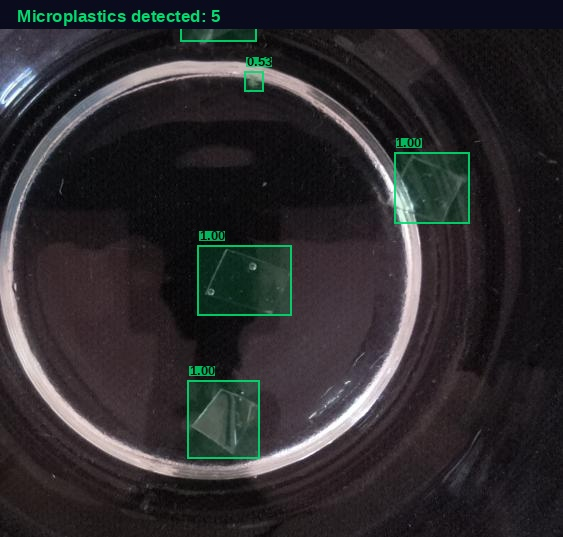


🌡️  Feature Heatmap (detected box regions):


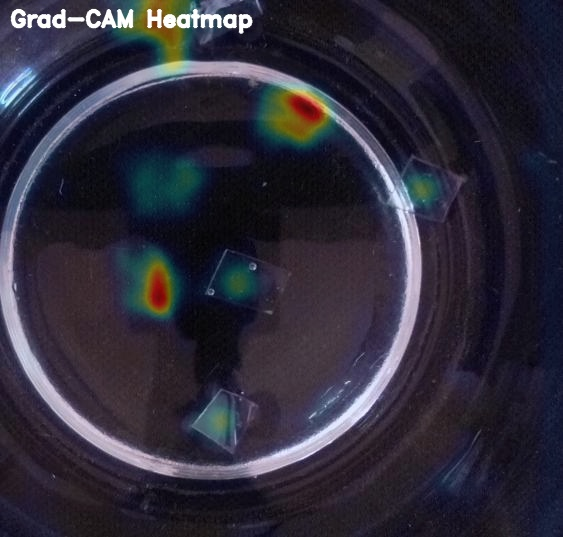


📋 Side-by-side:


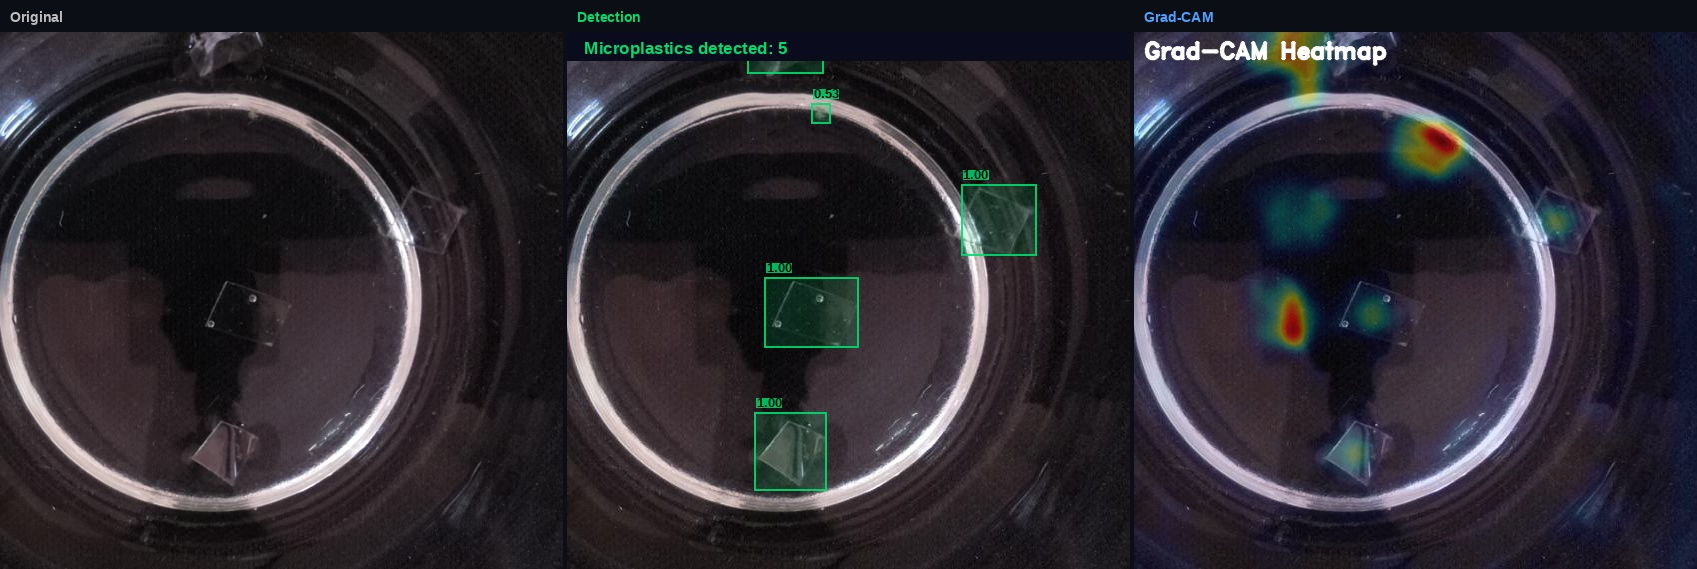

[INFO] Model loaded ✓
[INFO] Running detection ...
[INFO] Detected 4 microplastic(s)
[SAVED] /content/drive/MyDrive/Colab Notebooks/Dataset/dataset/outputs/a--7-_jpg.rf.39b8597ed074d53daeaf5daf76fb41ac_detected.jpg
[INFO] Computing feature heatmap ...
[SAVED] /content/drive/MyDrive/Colab Notebooks/Dataset/dataset/outputs/a--7-_jpg.rf.39b8597ed074d53daeaf5daf76fb41ac_gradcam.jpg
[SAVED] /content/drive/MyDrive/Colab Notebooks/Dataset/dataset/outputs/a--7-_jpg.rf.39b8597ed074d53daeaf5daf76fb41ac_side_by_side.jpg

📊 Microplastics detected: 4
   Confidence scores: ['0.999', '0.999', '0.999', '0.998']

🔍 Detection:


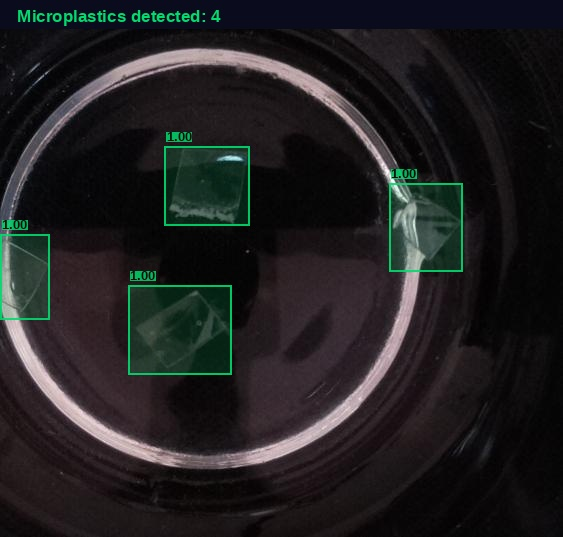


🌡️  Feature Heatmap (detected box regions):


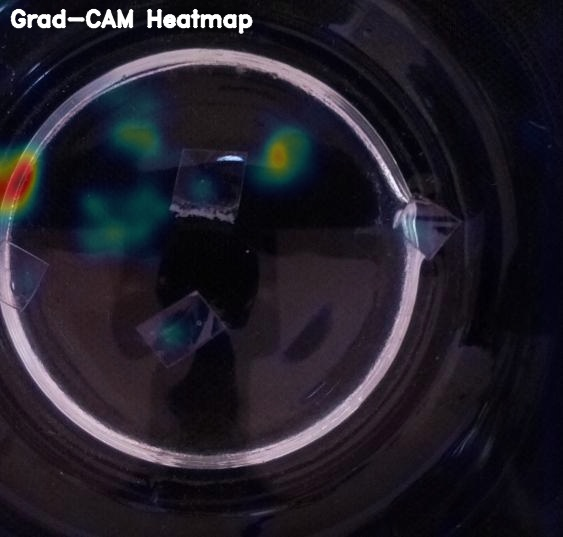


📋 Side-by-side:


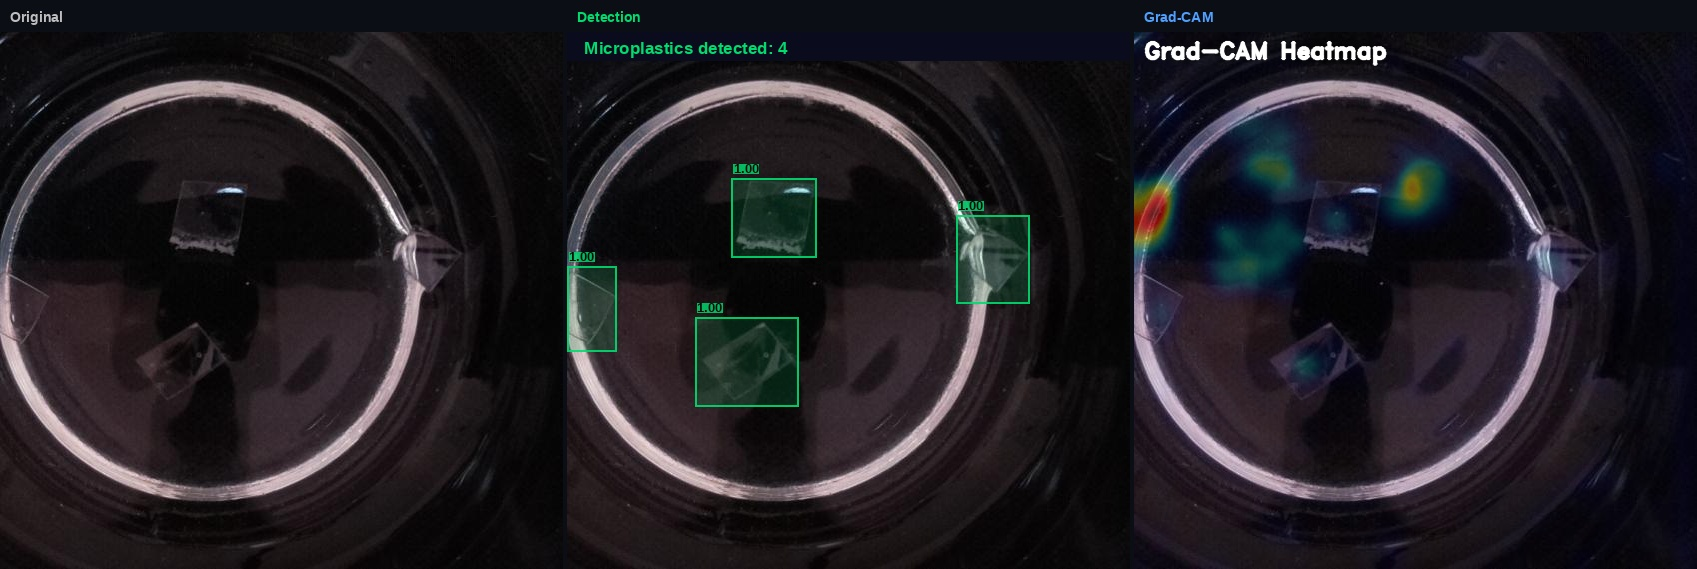

In [ ]:
exec(open('/content/drive/MyDrive/Colab Notebooks/Dataset/dataset/predict_and_gradcam_v2.py').read())

result = run_inference(
    "/content/drive/MyDrive/Colab Notebooks/Dataset/dataset/valid/a--7-_jpg.rf.39b8597ed074d53daeaf5daf76fb41ac.jpg"
)
display_results(result)

In [ ]:
!pip install grad-cam -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 68.6 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


[INFO] Device: cuda
[INFO] Model loaded ✓
[INFO] Detecting ...
[INFO] 5 microplastic(s) detected
[SAVED] /content/drive/MyDrive/Colab Notebooks/Dataset/dataset/outputs/a--3-_jpg.rf.8248ba99e3b3ae254d1723b674f7fd99_detected.jpg
[INFO] Computing Grad-CAM ...
[SAVED] /content/drive/MyDrive/Colab Notebooks/Dataset/dataset/outputs/a--3-_jpg.rf.8248ba99e3b3ae254d1723b674f7fd99_gradcam.jpg
[SAVED] /content/drive/MyDrive/Colab Notebooks/Dataset/dataset/outputs/a--3-_jpg.rf.8248ba99e3b3ae254d1723b674f7fd99_side_by_side.jpg

📊 Detected: 5 microplastic(s)
   Scores: ['1.000', '0.999', '0.999', '0.995', '0.534']

🔍 Detection:


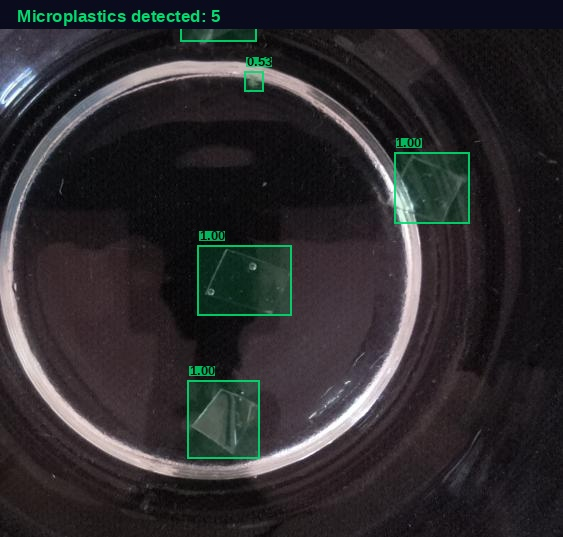


🌡️  Grad-CAM:


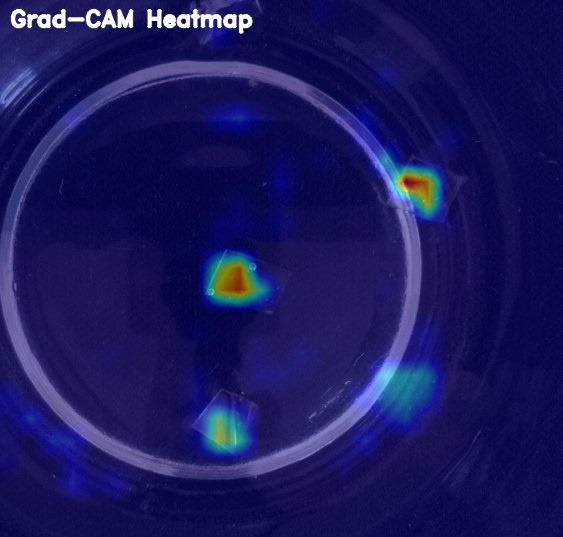


📋 Side-by-side:


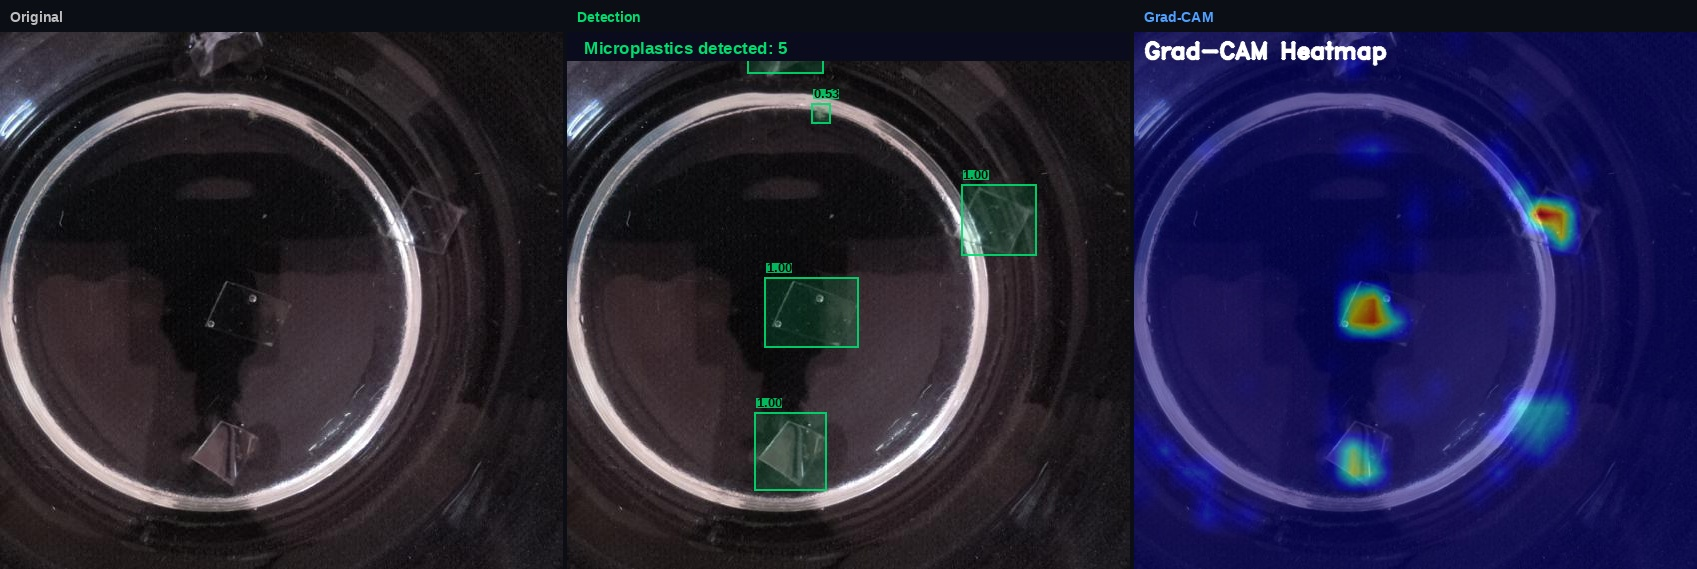

[INFO] Model loaded ✓
[INFO] Detecting ...
[INFO] 4 microplastic(s) detected
[SAVED] /content/drive/MyDrive/Colab Notebooks/Dataset/dataset/outputs/a--7-_jpg.rf.39b8597ed074d53daeaf5daf76fb41ac_detected.jpg
[INFO] Computing Grad-CAM ...
[SAVED] /content/drive/MyDrive/Colab Notebooks/Dataset/dataset/outputs/a--7-_jpg.rf.39b8597ed074d53daeaf5daf76fb41ac_gradcam.jpg
[SAVED] /content/drive/MyDrive/Colab Notebooks/Dataset/dataset/outputs/a--7-_jpg.rf.39b8597ed074d53daeaf5daf76fb41ac_side_by_side.jpg

📊 Detected: 4 microplastic(s)
   Scores: ['0.999', '0.999', '0.999', '0.998']

🔍 Detection:


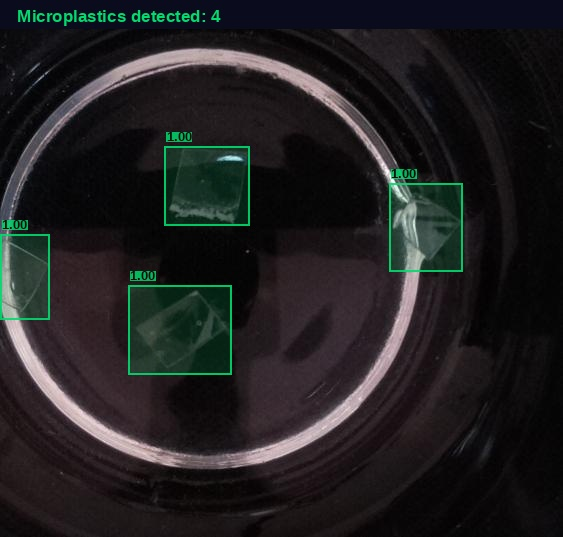


🌡️  Grad-CAM:


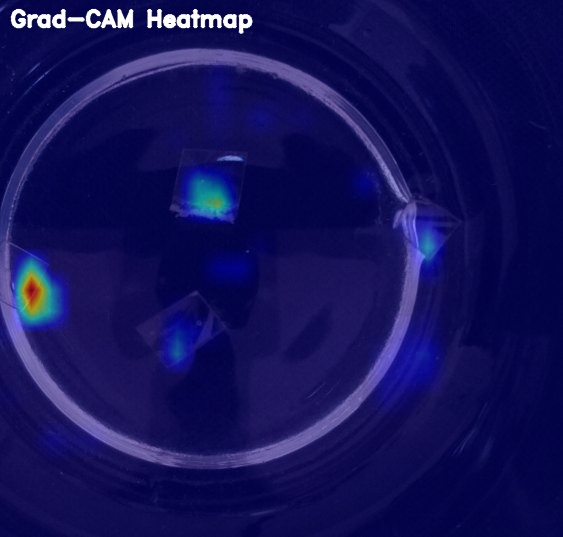


📋 Side-by-side:


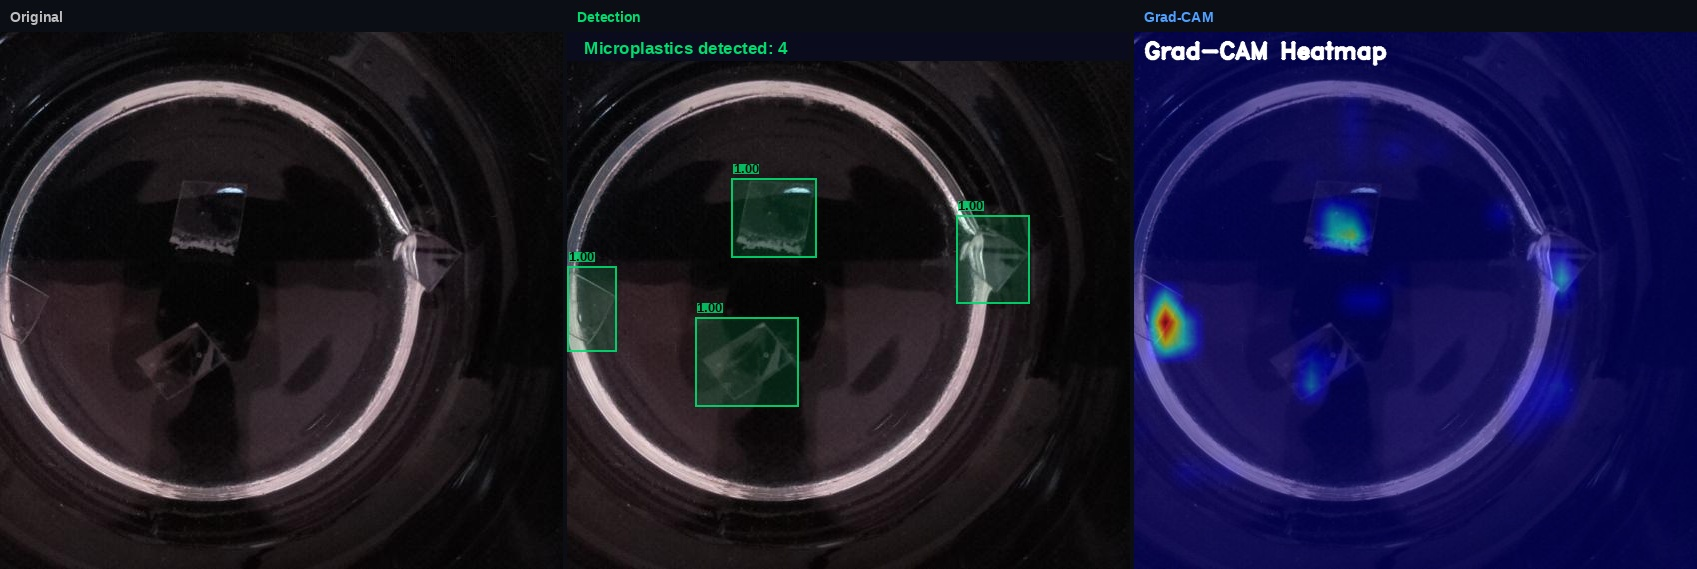

In [ ]:
# Cell 2 — run
exec(open('/content/drive/MyDrive/Colab Notebooks/Dataset/dataset/gradcam_visualizer.py').read())

result = generate_gradcam(
    "/content/drive/MyDrive/Colab Notebooks/Dataset/dataset/valid/a--7-_jpg.rf.39b8597ed074d53daeaf5daf76fb41ac.jpg"
)
show(result)